In [25]:
from paddleocr import PaddleOCR, draw_ocr
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd
import logging
import tqdm
import Levenshtein
import os
import re

mother_path = Path().resolve().parent
data_path = mother_path.joinpath('data')
arg_data = data_path.joinpath('arg_plate_dataset')
arg_train_datapath = arg_data.joinpath('train')
arg_val_datapath = arg_data.joinpath('valid')


In [20]:
# Read img path and label
df_train = pd.read_csv(arg_data/'train_anotaciones.csv')
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = pd.read_csv(arg_data/'valid_anotaciones.csv')

#### Set up image/label pair

In [21]:
def img_label(df):
    """
    Extract image path and label pair
    """
    image_paths = [os.path.join(arg_data, img) for img in df['image_path'].tolist()]
    labels = df['plate_text'].tolist()

    return image_paths, labels

In [22]:
train_img, train_labels = img_label(df_train)
val_img, val_labels = img_label(df_val)
test_img, test_labels = img_label(df_test)

### One image test

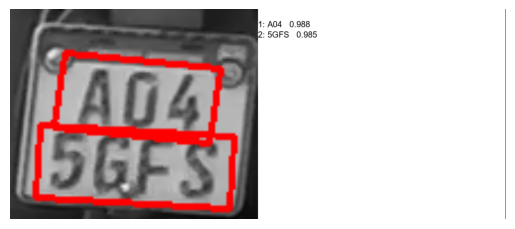

In [4]:
# Initialize the PaddleOCR model
ocr = PaddleOCR(use_angle_cls=True, lang='en', use_gpu = True)  # Set the language as needed

# Path to the image file
img_path_test = str(arg_train_datapath.joinpath("2020-01-08_1129-09_07_121.png"))

# Perform OCR on the image
result = ocr.ocr(img_path_test, cls=True)

# Extract the image with boxes
image = Image.open(img_path_test).convert('RGB')
boxes = [elements[0] for elements in result[0]]
txts = [elements[1][0] for elements in result[0]]
scores = [elements[1][1] for elements in result[0]]
font_path = "C:/Windows/Fonts/arial.ttf"
# Draw results on the image
im_show = draw_ocr(image, boxes, txts, scores, font_path=font_path)
im_show = Image.fromarray(im_show)

# Display the image
plt.imshow(im_show)
plt.axis('off')
plt.show()


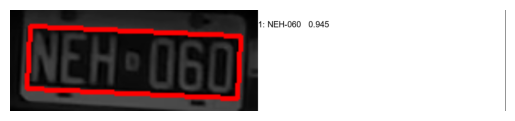

In [5]:
# Path to the image file
img_path_test = str(arg_train_datapath.joinpath("2020-16-07_1231-31_14_245.png"))

# Perform OCR on the image
result = ocr.ocr(img_path_test, cls=True)

# Extract the image with boxes
image = Image.open(img_path_test).convert('RGB')
boxes = [elements[0] for elements in result[0]]
txts = [elements[1][0] for elements in result[0]]
scores = [elements[1][1] for elements in result[0]]
font_path = "C:/Windows/Fonts/arial.ttf"
# Draw results on the image
im_show = draw_ocr(image, boxes, txts, scores, font_path=font_path)
im_show = Image.fromarray(im_show)

# Display the image
plt.imshow(im_show)
plt.axis('off')
plt.show()


##### Test base model

In [ ]:
model_path = Path().resolve().joinpath('models')
det = 'en_PP-OCRv3_det_infer'
rec = 'en_PP-OCRv4_rec_infer'

In [46]:
# Initialize PaddleOCR with GPU enabled
ocr = PaddleOCR(
    use_angle_cls=False, 
    lang="en", 
    use_gpu=True, 
    det_model_dir=str(model_path/det), 
    rec_model_dir=str(model_path/rec)
)


# Suppress PaddleOCR logs
logging.getLogger("ppocr").setLevel(logging.ERROR)

# Function to perform OCR on an image
def ocr_predict(image_path):
    result = ocr.ocr(image_path, cls=True)
    if result and result[0]:  
        detected_text = "".join([res[1][0] for res in result[0]])  # Concatenate detected text
        return detected_text  # Clean the OCR result
    return ""

# Track incorrect predictions and CER calculation
incorrect_samples = []
total_cer = 0  # Total character error rate
correct = 0
total = 0  # Track total valid samples

for _, row in tqdm.tqdm(df_test.iterrows(), total=len(df_test)):
    img_path = arg_data / row["image_path"]
    
    if not img_path.exists():
        print(f"Warning: {img_path} not found, skipping...")
        continue  # Skip missing images
    
    total += 1  # Count only valid images
    
    predicted_text = ocr_predict(str(img_path))
    true_text = row["plate_text"]  # Clean ground truth for fair comparison

    # Compute Character Error Rate (CER)
    cer = Levenshtein.distance(predicted_text, true_text) / max(len(true_text), 1)
    total_cer += cer

    # Compare predictions with ground truth
    if predicted_text == true_text:
        correct += 1
    else:
        # Store incorrect results
        incorrect_samples.append({
            "Image Path": str(img_path),
            "True Text": true_text,
            "Predicted Text": predicted_text,
            "CER": cer
        })

# Compute accuracy
accuracy = (correct / total) * 100 if total > 0 else 0
avg_cer = (total_cer / total) if total > 0 else 0  # Compute average CER

print(f"Paddle OCR Accuracy on Validation Set: {accuracy:.2f}%")
print(f"PaddleAverage Character Error Rate (CER): {avg_cer:.4f}")


100%|██████████| 763/763 [00:07<00:00, 96.05it/s] 

Paddle OCR Accuracy on Validation Set: 35.65%
PaddleAverage Character Error Rate (CER): 0.1794


##### Update the text decoding method

In [47]:
# Function to clean OCR output
def clean_text(text):
    """Removes all non-alphanumeric characters and normalizes text."""
    text = re.sub(r'[^A-Z0-9]', '', text.upper())  # Keep only A-Z and 0-9
    text = text.replace("O", "0").replace("I", "1")  # Fix common OCR mistakes
    return text

# Track incorrect predictions and CER calculation
incorrect_samples = []
total_cer = 0  # Total character error rate
correct = 0
total = 0  # Track total valid samples

for _, row in tqdm.tqdm(df_test.iterrows(), total=len(df_test)):
    img_path = arg_data / row["image_path"]
    
    if not img_path.exists():
        print(f"Warning: {img_path} not found, skipping...")
        continue  # Skip missing images
    
    total += 1  # Count only valid images
    
    predicted_text = clean_text(ocr_predict(str(img_path)))
    true_text = clean_text(row["plate_text"])  # Clean ground truth for fair comparison

    # Compute Character Error Rate (CER)
    cer = Levenshtein.distance(predicted_text, true_text) / max(len(true_text), 1)
    total_cer += cer

    # Compare predictions with ground truth
    if predicted_text == true_text:
        correct += 1
    else:
        # Store incorrect results
        incorrect_samples.append({
            "Image Path": str(img_path),
            "True Text": true_text,
            "Predicted Text": predicted_text,
            "CER": cer
        })

# Compute accuracy
accuracy = (correct / total) * 100 if total > 0 else 0
avg_cer = (total_cer / total) if total > 0 else 0  # Compute average CER

print(f"Paddle OCR Accuracy on Validation Set: {accuracy:.2f}%")
print(f"PaddleAverage Character Error Rate (CER): {avg_cer:.4f}")


100%|██████████| 763/763 [00:07<00:00, 98.70it/s] 

Paddle OCR Accuracy on Validation Set: 84.14%
PaddleAverage Character Error Rate (CER): 0.0835


### Fine-tune

This model will be fine tuned in terminal

In [ ]:
# Prepare data to fine tune
train_img[:5]

['C:\\Users\\zeyuz\\Desktop\\Projects\\Car-Plate-detection-OCR\\data\\arg_plate_dataset\\train/2020-15-07_0832-40_13_861.png',
 'C:\\Users\\zeyuz\\Desktop\\Projects\\Car-Plate-detection-OCR\\data\\arg_plate_dataset\\train/2020-12-08_2223-32_40_3931_AA974KE-P_63.9.png',
 'C:\\Users\\zeyuz\\Desktop\\Projects\\Car-Plate-detection-OCR\\data\\arg_plate_dataset\\train/2020-12-08_2038-38_33_5589_PIQ218_-P_49.23.png',
 'C:\\Users\\zeyuz\\Desktop\\Projects\\Car-Plate-detection-OCR\\data\\arg_plate_dataset\\train/A994SXF.jpg',
 'C:\\Users\\zeyuz\\Desktop\\Projects\\Car-Plate-detection-OCR\\data\\arg_plate_dataset\\train/2020-14-07_1705-38_94_315.png']

In [50]:
train_labels[:5]

['JPJ174', 'AA974KE', 'PIQ218', 'A994SXF', 'AD631SM']

In [53]:
def write_label_file(img_paths, labels, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        for img_path, label in zip(img_paths, labels):
            f.write(f"{img_path}\t{label}\n")

train_list_path = str(arg_data/"train_list.txt")
val_list_path = str(arg_data/"val_list.txt")

In [55]:
write_label_file(train_img, train_labels, train_list_path)
write_label_file(val_img, val_labels, val_list_path)